# Análisis exploratorio dataset - Airbnb

## Introducción

In [10]:
import numpy  as np  
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### 1. Carga de datos y división train/test

Para esta exploración de datos, se decide crear dos archivos train/test para la exploración de los datos y construcción del modelo, esto nos permite evitar el data leakage. Adicional se define que lo datos van a estar separados en 70% Train y 30% Test.

In [11]:
# Importamos la librería para dividir el dataset en train y test
from sklearn.model_selection import train_test_split

# Cargamos el dataset completo en un DataFrame de pandas "full_df"
full_df = pd.read_csv("./airbnb-listings-extract.csv", delimiter=';')
train, test = train_test_split(full_df, test_size=0.3, shuffle=True, random_state=0)

# Dimensiones de los datasets de training y test
print('Dimensiones de los datasets:')
print(f'Original 100% de los datos: {full_df.shape}')
print(f'Training 70% de los datos: {train.shape}')
print(f'Test 30% de los datos: {test.shape}')

# Se guardan los datasets de training y test en formato CSV, con el separador ';' y el decimal '.'
train.to_csv('./airbnb_train.csv', sep=';', decimal='.', index=False)
test.to_csv('./airbnb_test.csv', sep=';', decimal='.', index=False)

Dimensiones de los datasets:
Original 100% de los datos: (14780, 89)
Training 70% de los datos: (10346, 89)
Test 30% de los datos: (4434, 89)


Carga y exploración de la información del Dataset

### 2. Análisis exploratorio

In [12]:
# Cargamos el dataset de training en un DataFrame de pandas "airbnb_df"
airbnb_df_full = pd.read_csv('./airbnb_train.csv', sep=';', decimal='.')

# Mostramos las primeras 5 filas del dataset de training (la funcion .T nos permite mostrar las filas como columnas)
airbnb_df_full.head(5)

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,2156319,https://www.airbnb.com/rooms/2156319,20170407214119,2017-04-08,GRANT VII Plaza Mayor,NaN,Beautiful and charming apartment recently deco...,Beautiful and charming apartment recently deco...,none,NaN,...,9.0,10.0,9.0,NaN,NaN,strict,40.0,0.24,"40.4154180336,-3.70712273935","Host Has Profile Pic,Host Identity Verified,Is..."
1,3377153,https://www.airbnb.com/rooms/3377153,20170407214119,2017-04-08,Nice flat in Plaza Mayor (lift),"Flat is in the centre town, really close to Pl...",You cannot find a better location to stay in M...,"Flat is in the centre town, really close to Pl...",none,"It´s really cool, with a lot of new business (...",...,10.0,10.0,9.0,NaN,NaN,flexible,1.0,5.61,"40.411131472,-3.7072583983","Host Has Profile Pic,Host Identity Verified,Is..."
2,14800635,https://www.airbnb.com/rooms/14800635,20170407214119,2017-04-08,* ROOM double Barrio Salamanca *,"Private room for two persons has a double bed,...",It is a penthouse located in the salamanca dis...,"Private room for two persons has a double bed,...",none,The District of Salamanca is one of the 21 dis...,...,10.0,10.0,10.0,NaN,NaN,flexible,3.0,5.45,"40.4280496724,-3.6760419089","Host Has Profile Pic,Host Identity Verified,Re..."
3,11185674,https://www.airbnb.com/rooms/11185674,20170407214119,2017-04-08,cheap apartment in Madrid city cent,"Cheap apartment, next to Madrid rio, just four...",NaN,"Cheap apartment, next to Madrid rio, just four...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,flexible,1.0,0.16,"40.3964492726,-3.71409988867","Host Has Profile Pic,Is Location Exact,Require..."
4,18092171,https://www.airbnb.com/rooms/18092171,20170407214119,2017-04-08,"ACOGEDOR APARTAMENTO EN MADRID, CALLE MANZANARES","Acogedor apartamento, para parejas y/o familia.",NaN,"Acogedor apartamento, para parejas y/o familia.",none,NaN,...,NaN,NaN,NaN,NaN,NaN,strict,3.0,NaN,"40.4134467958,-3.71843838152","Host Has Profile Pic,Is Location Exact,Require..."


In [13]:
#Se validan todas las columnas del Dataset, cantidad de nulos y tipo de dato.
airbnb_df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10346 entries, 0 to 10345
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              10346 non-null  int64  
 1   Listing Url                     10346 non-null  object 
 2   Scrape ID                       10346 non-null  int64  
 3   Last Scraped                    10346 non-null  object 
 4   Name                            10345 non-null  object 
 5   Summary                         9922 non-null   object 
 6   Space                           7619 non-null   object 
 7   Description                     10340 non-null  object 
 8   Experiences Offered             10346 non-null  object 
 9   Neighborhood Overview           6397 non-null   object 
 10  Notes                           3960 non-null   object 
 11  Transit                         6327 non-null   object 
 12  Access                          

In [14]:
#Columnas consultadas para evaluar su contenido y determinar si se eliminan

airbnb_df_full[['ID','Neighbourhood','Neighbourhood Cleansed','Neighbourhood Group Cleansed']]

#airbnb_df_full[['ID','Market']]
#airbnb_df_full['Market'].value_counts()

airbnb_df_full[['ID','Smart Location']]
airbnb_df_full['Smart Location'].value_counts()

#airbnb_df_full[['ID','Country Code']]

#airbnb_df_full[['ID','Property Type']]
#airbnb_df_full['Property Type'].value_counts()

#airbnb_df_full[['ID','Room Type']]

#airbnb_df_full[['ID','Accommodates']]
#airbnb_df_full['Accommodates'].value_counts()

#airbnb_df_full[['ID','Square Feet']]
#airbnb_df_full['Square Feet'].value_counts()

#airbnb_df_full[['ID','Calculated host listings count']]
#airbnb_df_full[['ID','Features']]

airbnb_df_full[['ID','Country']]
airbnb_df_full['Country'].value_counts()

Country
Spain             9817
United Kingdom     118
United States      115
France              72
Italy               51
Australia           33
Germany             30
Ireland             23
Austria             22
Netherlands         16
Canada              14
Belgium             14
Denmark             10
Switzerland          4
Greece               3
Hong Kong            2
Cuba                 1
Name: count, dtype: int64

In [28]:
#Extraemos las columnas que consideramos mas relevantes por nombre de la columna
#(sentido común y validando el contenido) a un nuevo df

airbnb_df = airbnb_df_full[['ID', 'Street', 'Neighbourhood', 'Neighbourhood Cleansed',
                             'Neighbourhood Group Cleansed', 'City', 'State', 'Smart Location',
                             'Country Code', 'Country','Property Type','Room Type','Accommodates',
                             'Bathrooms','Bedrooms','Price','Number of Reviews','First Review','Last Review',
                             'Reviews per Month']]

In [29]:
#Exploramos los registros con valor null y se reemplzan manualmente de acuerdo a la 
# información de otras columnas.

airbnb_df[airbnb_df['City'].isna()]
airbnb_df['City'].value_counts()
airbnb_df['City'].fillna('Madrid', inplace=True)
vcity_na = [1736, 1963, 4086, 4549]
airbnb_df.iloc[vcity_na]

airbnb_df[airbnb_df['Country'].isna()]
airbnb_df['Country'].value_counts()
airbnb_df['Country'].fillna('Spain', inplace=True)
airbnb_df[2231:2232]
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10346 entries, 0 to 10345
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10346 non-null  int64  
 1   Street                        10346 non-null  object 
 2   Neighbourhood                 6706 non-null   object 
 3   Neighbourhood Cleansed        10346 non-null  object 
 4   Neighbourhood Group Cleansed  9645 non-null   object 
 5   City                          10346 non-null  object 
 6   State                         10240 non-null  object 
 7   Smart Location                10346 non-null  object 
 8   Country Code                  10346 non-null  object 
 9   Country                       10346 non-null  object 
 10  Property Type                 10346 non-null  object 
 11  Room Type                     10346 non-null  object 
 12  Accommodates                  10346 non-null  int64  
 13  B

In [30]:
#El 95% de los datos corresponden a España, por lo que se determina que el modelo solo funcionaran 
# para España por que los datos de otros paises no son suficientes, solo nos quedamos con estos registros

airbnb_df = airbnb_df[airbnb_df['Country'] == 'Spain']
print(f'Nuevo dataset: {airbnb_df.shape}')

Nuevo dataset: (9818, 20)


In [31]:
#Validamos los campos numericos con nulos e imputamos los datos.
airbnb_df['Bathrooms'].value_counts()
airbnb_df['Bathrooms'].fillna(airbnb_df['Bathrooms'].mode()[0], inplace=True)

airbnb_df['Bedrooms'].value_counts()
airbnb_df['Bedrooms'].fillna(airbnb_df['Bedrooms'].mode()[0], inplace=True)

airbnb_df['Price'].fillna(airbnb_df['Price'].mode()[0], inplace=True)

airbnb_df.isnull().any()

ID                              False
Street                          False
Neighbourhood                    True
Neighbourhood Cleansed          False
Neighbourhood Group Cleansed     True
City                            False
State                            True
Smart Location                  False
Country Code                    False
Country                         False
Property Type                   False
Room Type                       False
Accommodates                    False
Bathrooms                       False
Bedrooms                        False
Price                           False
Number of Reviews               False
First Review                     True
Last Review                      True
Reviews per Month                True
dtype: bool

In [32]:
# Se eliminan las columnas que no es posible imputar
airbnb_df = airbnb_df.drop(['ID','Neighbourhood','Neighbourhood Group Cleansed','State','First Review','Last Review','Reviews per Month'], axis=1)
airbnb_df.isnull().any()

Street                    False
Neighbourhood Cleansed    False
City                      False
Smart Location            False
Country Code              False
Country                   False
Property Type             False
Room Type                 False
Accommodates              False
Bathrooms                 False
Bedrooms                  False
Price                     False
Number of Reviews         False
dtype: bool

In [34]:
#Reemplazo de nombres y verificación de la información
airbnb_df.columns = ['Street', 'Neighbourhood', 'City', 'Smart_Location',
                     'Country_Code', 'Country', 'Property_Type', 'Room_Type', 'Accommodates',
                     'Bathrooms','Bedrooms','Price','Total_Reviews']
print('datset: airbnb_df')
airbnb_df.info()

datset: airbnb_df
<class 'pandas.core.frame.DataFrame'>
Index: 9818 entries, 0 to 10345
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Street          9818 non-null   object 
 1   Neighbourhood   9818 non-null   object 
 2   City            9818 non-null   object 
 3   Smart_Location  9818 non-null   object 
 4   Country_Code    9818 non-null   object 
 5   Country         9818 non-null   object 
 6   Property_Type   9818 non-null   object 
 7   Room_Type       9818 non-null   object 
 8   Accommodates    9818 non-null   int64  
 9   Bathrooms       9818 non-null   float64
 10  Bedrooms        9818 non-null   float64
 11  Price           9818 non-null   float64
 12  Total_Reviews   9818 non-null   int64  
dtypes: float64(3), int64(2), object(8)
memory usage: 1.0+ MB


In [35]:
#Aplicamos el enconder para convertir todas las variables de tipo object
#El TargetEncoder se puede utilizar pero es necesario hacer la categorización con la variable objetivo,
# que buscando un información genera Data Lakage y Overfitting, por lo que la opción es utilizar OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
airbnb_df[['Street']] = encoder.fit_transform(airbnb_df[['Street']])
airbnb_df[['Neighbourhood']] = encoder.fit_transform(airbnb_df[['Neighbourhood']])
airbnb_df[['City']] = encoder.fit_transform(airbnb_df[['City']])
airbnb_df[['Smart_Location']] = encoder.fit_transform(airbnb_df[['Smart_Location']])
airbnb_df[['Country_Code']] = encoder.fit_transform(airbnb_df[['Country_Code']])
airbnb_df[['Country']] = encoder.fit_transform(airbnb_df[['Country']])
airbnb_df[['Property_Type']] = encoder.fit_transform(airbnb_df[['Property_Type']])
airbnb_df[['Room_Type']] = encoder.fit_transform(airbnb_df[['Room_Type']])
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9818 entries, 0 to 10345
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Street          9818 non-null   object 
 1   Neighbourhood   9818 non-null   float64
 2   City            9818 non-null   float64
 3   Smart_Location  9818 non-null   float64
 4   Country_Code    9818 non-null   float64
 5   Country         9818 non-null   float64
 6   Property_Type   9818 non-null   float64
 7   Room_Type       9818 non-null   float64
 8   Accommodates    9818 non-null   int64  
 9   Bathrooms       9818 non-null   float64
 10  Bedrooms        9818 non-null   float64
 11  Price           9818 non-null   float64
 12  Total_Reviews   9818 non-null   int64  
dtypes: float64(10), int64(2), object(1)
memory usage: 1.0+ MB


### 3. Visualización de variables

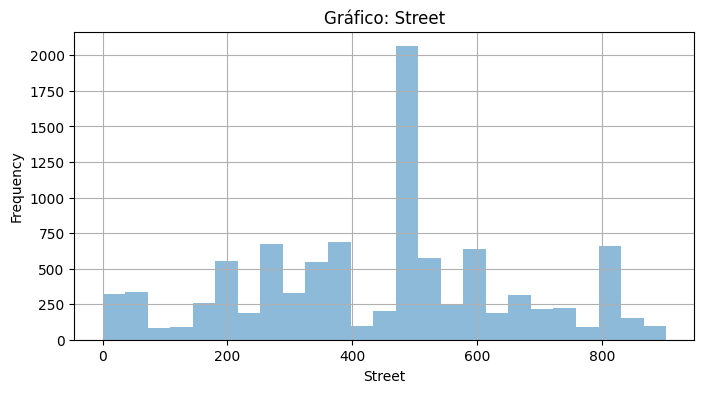

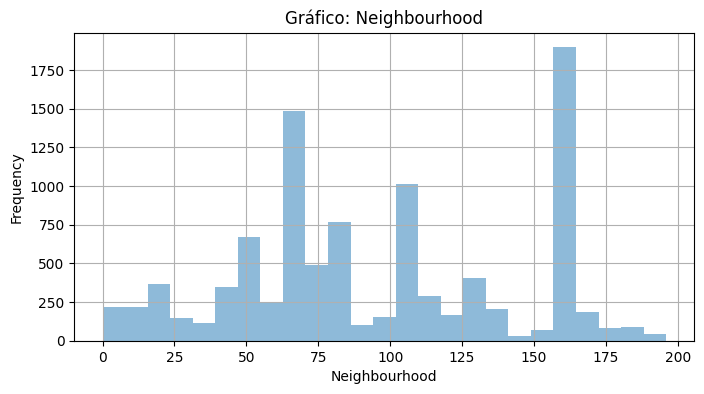

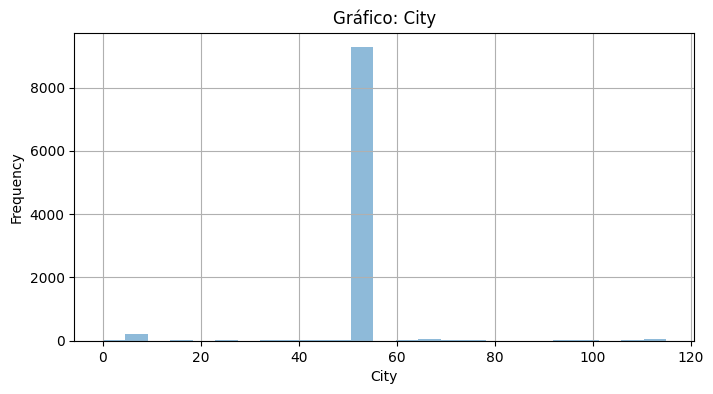

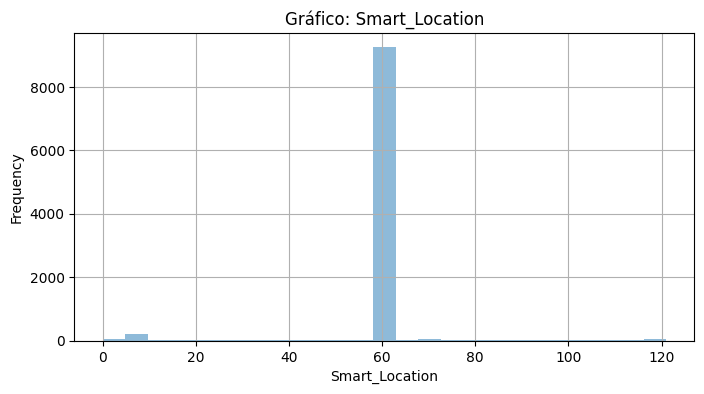

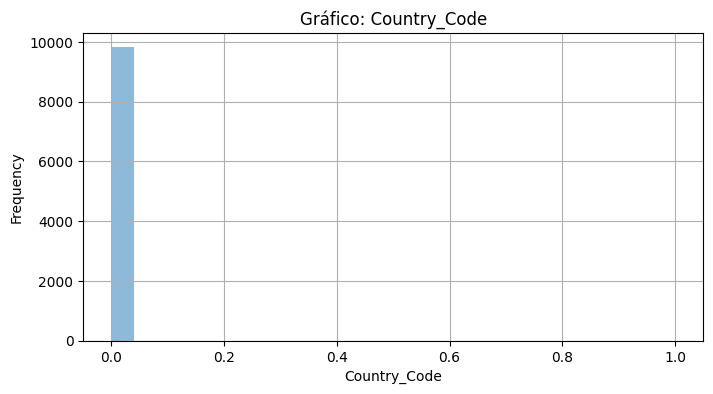

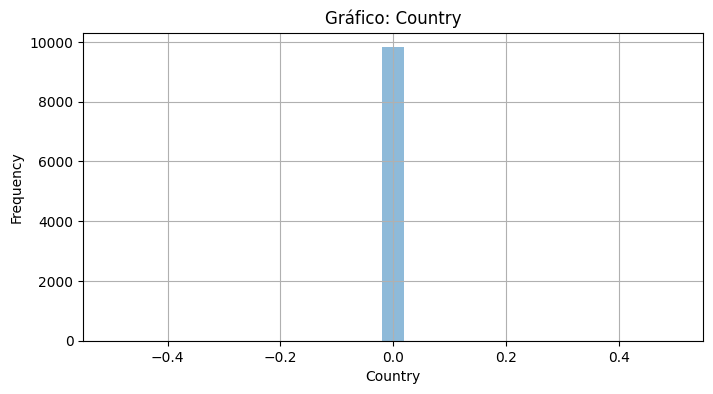

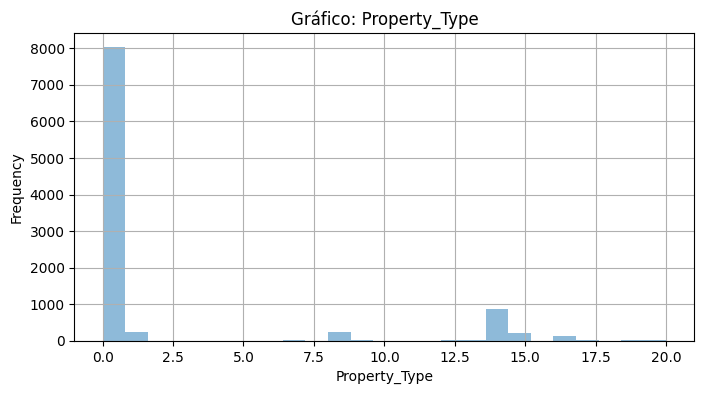

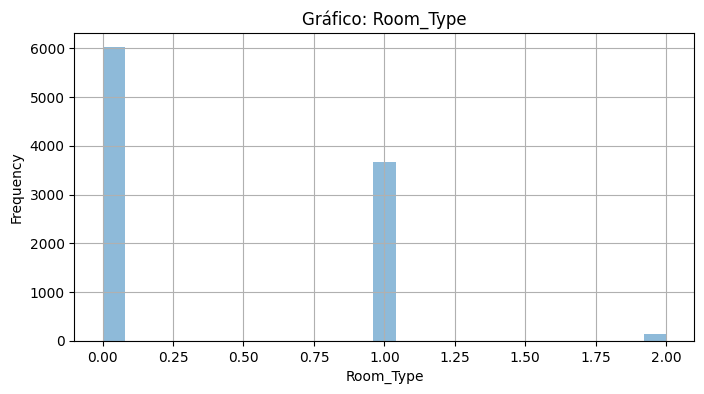

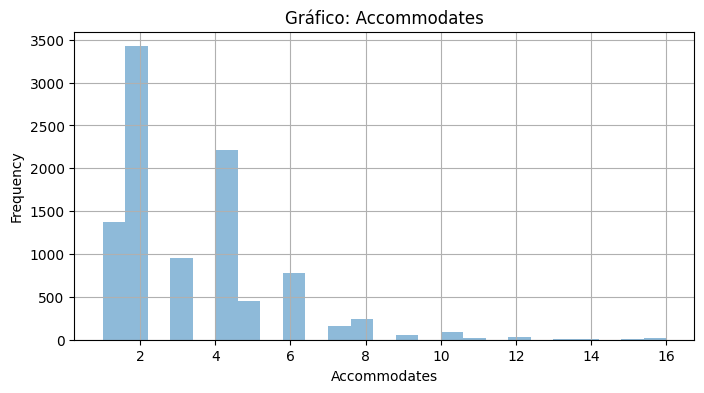

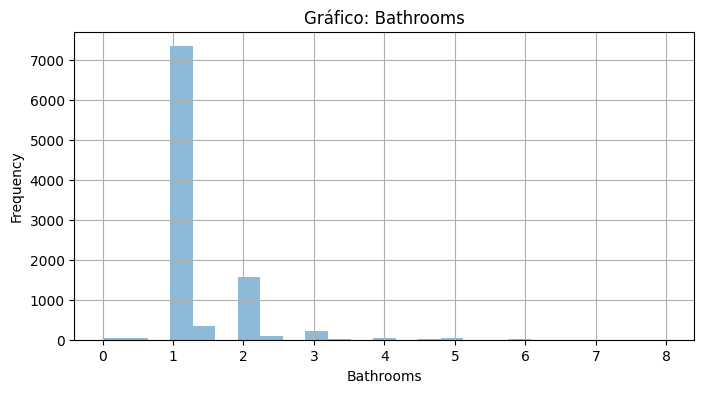

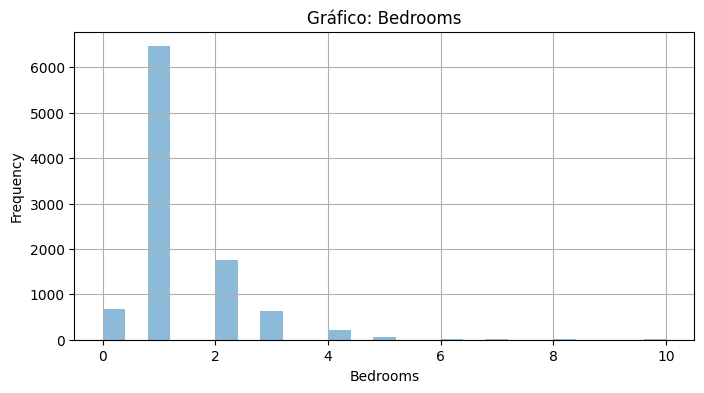

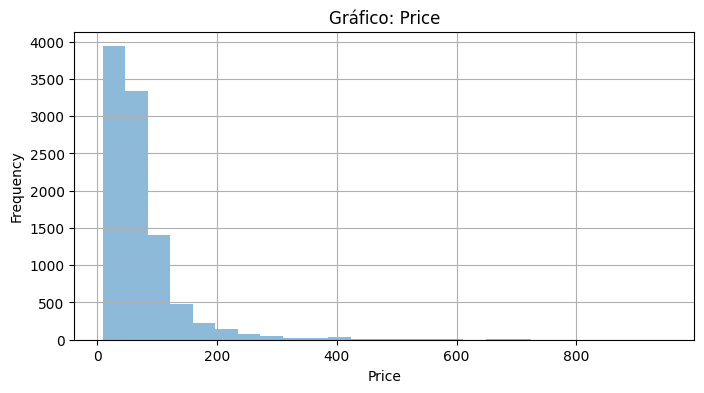

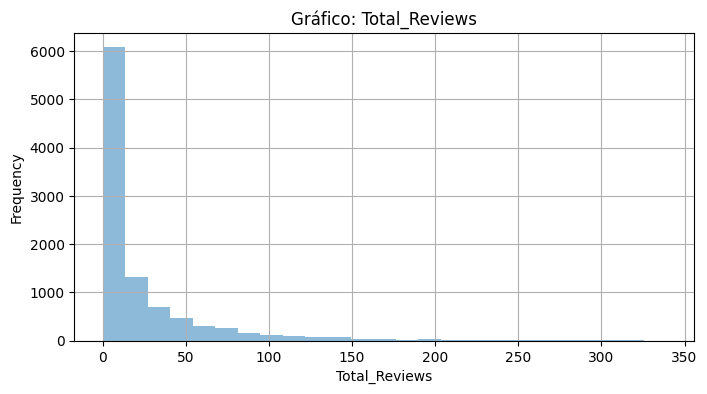

In [47]:
#Graficamos en un histograma
for c in airbnb_df.columns:
    plt.figure(figsize=(8, 4))
    airbnb_df[c].plot.hist(alpha=0.5, bins=25, grid = True)
    plt.title(f'Gráfico: {c}')
    plt.xlabel(c)

plt.show()

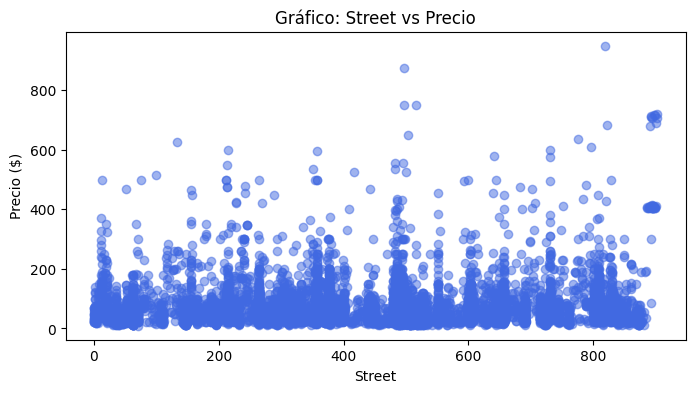

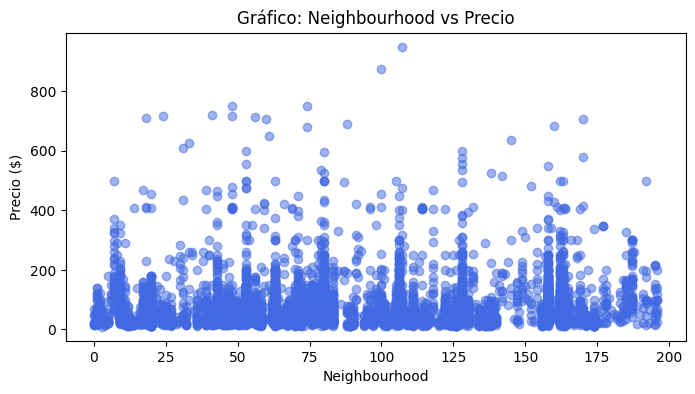

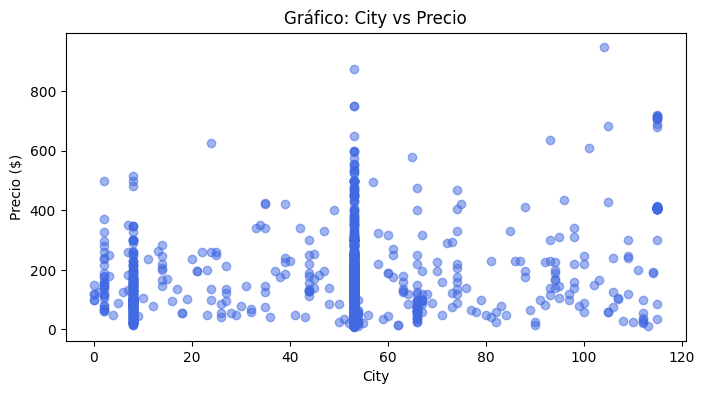

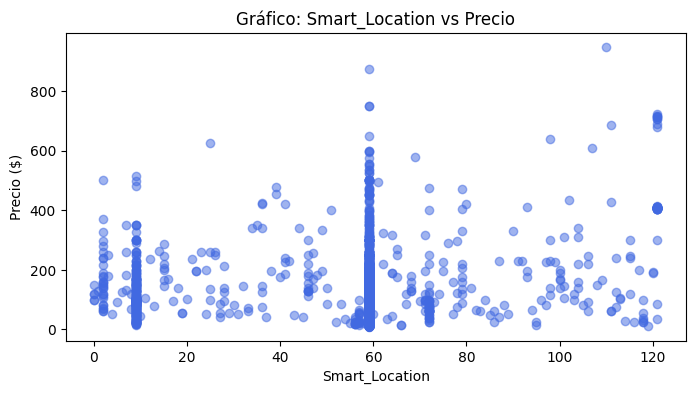

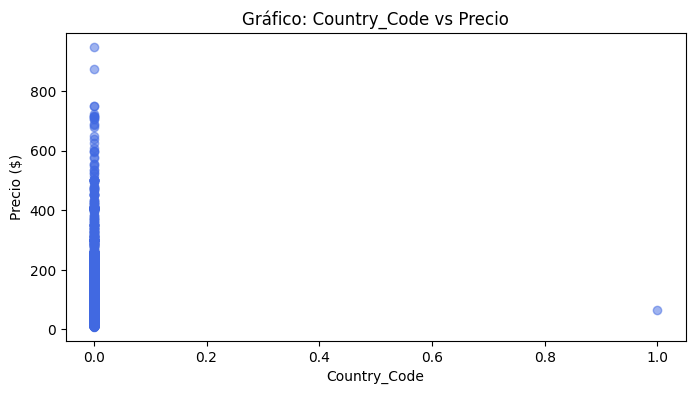

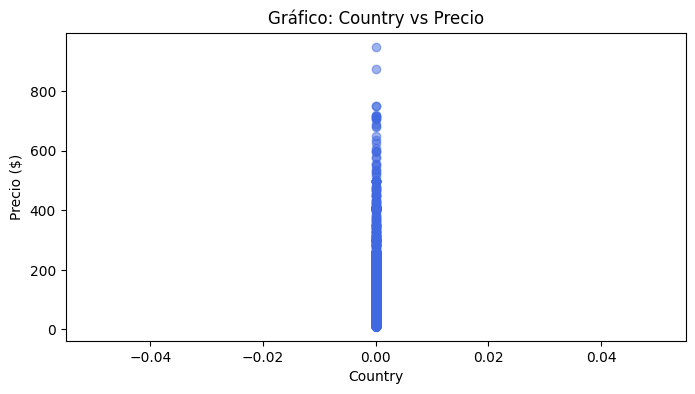

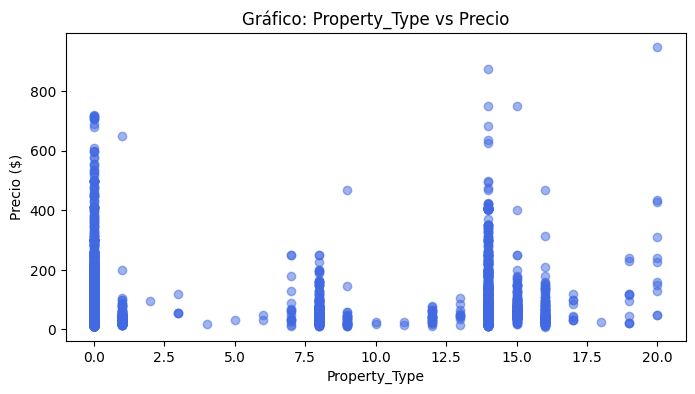

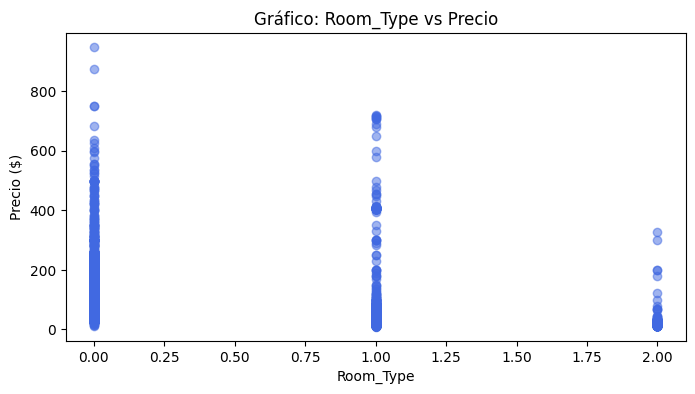

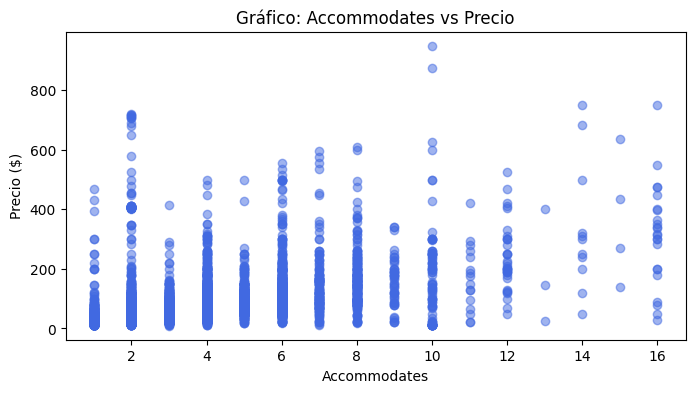

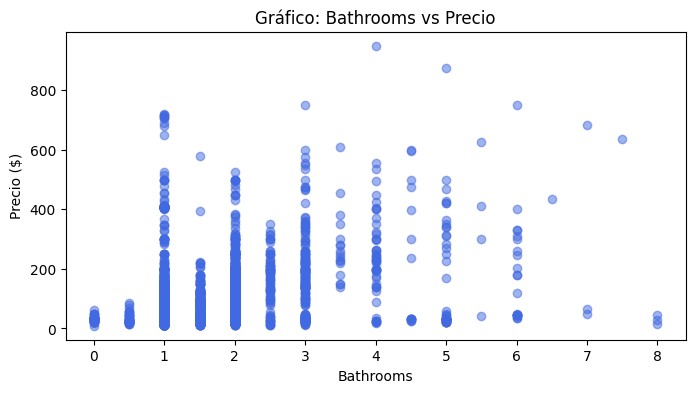

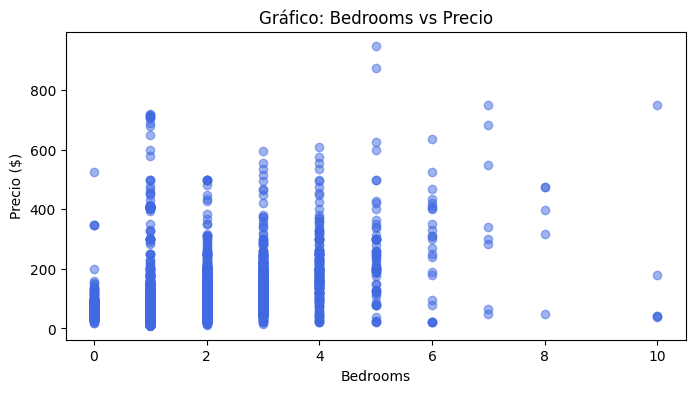

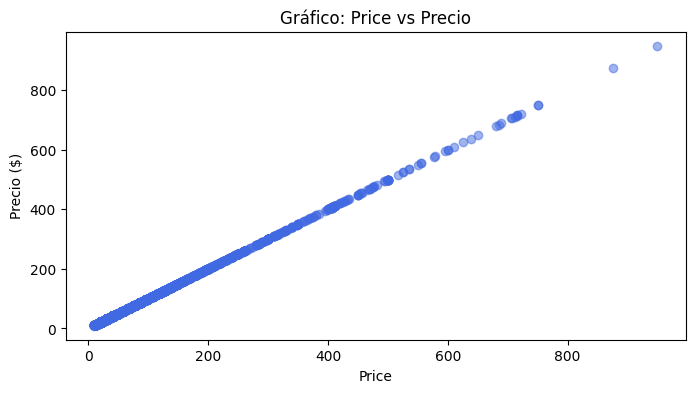

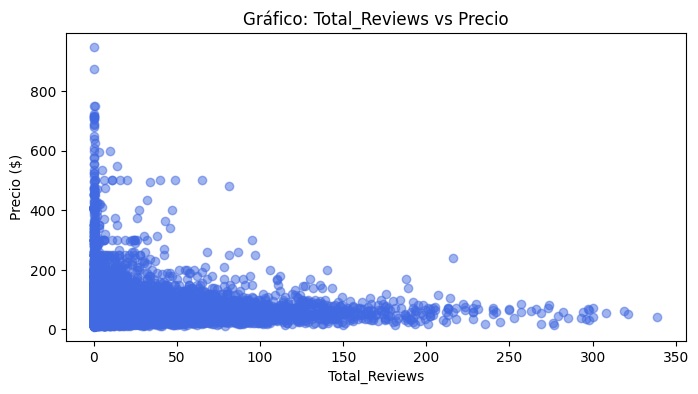

In [48]:
#Graficamos en un histograma
for c in airbnb_df.columns:
    plt.figure(figsize=(8, 4))
    plt.scatter(airbnb_df[c], airbnb_df['Price'], alpha=0.5, color='royalblue')
    plt.title(f'Gráfico: {c} vs Precio')
    plt.xlabel(c)
    plt.ylabel('Precio ($)')

plt.show()

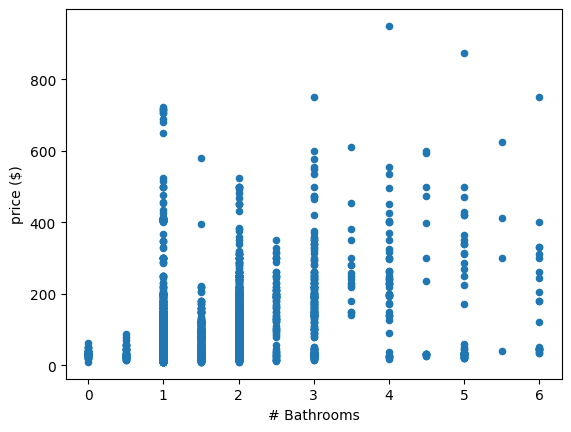

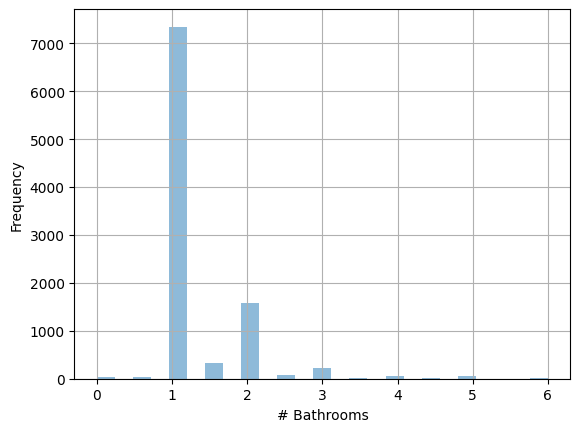

In [68]:
#Limpiar Outliers Bathrooms
airbnb_df_no_outliers_bathrooms = airbnb_df[airbnb_df['Bathrooms'] <= 6]

airbnb_df_no_outliers_bathrooms.plot(kind = 'scatter',x='Bathrooms',y = 'Price')
plt.xlabel('# Bathrooms')
plt.ylabel('price ($)')
plt.show()

airbnb_df_no_outliers_bathrooms['Bathrooms'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.xlabel('# Bathrooms')
plt.show()

In [66]:
print(f'Outliers Bathrooms')
print(    
    f'Original: {airbnb_df.shape[0]} // '
    f'Modificado: {airbnb_df_no_outliers_bathrooms.shape[0]}\nDiferencia: {airbnb_df.shape[0] - airbnb_df_no_outliers_bathrooms.shape[0]}'
)
print(f'Variación: {((airbnb_df.shape[0] - airbnb_df_no_outliers_bathrooms.shape[0])/airbnb_df.shape[0])*100:2f}%')

Outliers Bathrooms
Original: 9818 // Modificado: 9810
Diferencia: 8
Variación: 0.081483%


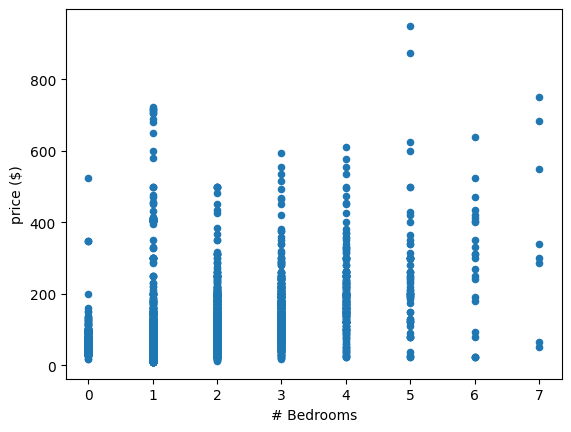

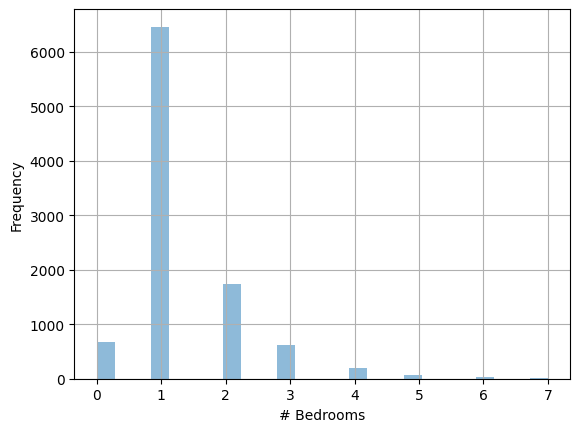

In [71]:
#Limpiar Outliers Bedrooms
airbnb_df_no_outliers_bedrooms = airbnb_df[airbnb_df['Bedrooms'] <= 7]

airbnb_df_no_outliers_bedrooms.plot(kind = 'scatter',x='Bedrooms',y = 'Price')
plt.xlabel('# Bedrooms')
plt.ylabel('price ($)')
plt.show()

airbnb_df_no_outliers_bedrooms['Bedrooms'].plot.hist(alpha=0.5, bins=25, grid = True)
plt.xlabel('# Bedrooms')
plt.show()

In [72]:
print(f'Outliers Bedrooms')
print(    
    f'Original: {airbnb_df.shape[0]} // '
    f'Modificado: {airbnb_df_no_outliers_bedrooms.shape[0]}\nDiferencia: {airbnb_df.shape[0] - airbnb_df_no_outliers_bedrooms.shape[0]}'
)
print(f'Variación: {((airbnb_df.shape[0] - airbnb_df_no_outliers_bedrooms.shape[0])/airbnb_df.shape[0])*100:2f}%')

Outliers Bedrooms
Original: 9818 // Modificado: 9808
Diferencia: 10
Variación: 0.101854%


In [73]:
### Se actualiza dataset
airbnb_df = airbnb_df[airbnb_df['Bathrooms'] <= 6]
airbnb_df = airbnb_df[airbnb_df['Bedrooms'] <= 7]
airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9801 entries, 0 to 10345
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Street          9801 non-null   float64
 1   Neighbourhood   9801 non-null   float64
 2   City            9801 non-null   float64
 3   Smart_Location  9801 non-null   float64
 4   Country_Code    9801 non-null   float64
 5   Country         9801 non-null   float64
 6   Property_Type   9801 non-null   float64
 7   Room_Type       9801 non-null   float64
 8   Accommodates    9801 non-null   int64  
 9   Bathrooms       9801 non-null   float64
 10  Bedrooms        9801 non-null   float64
 11  Price           9801 non-null   float64
 12  Total_Reviews   9801 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 1.0 MB


In [75]:
#Matriz de correlación
airbnb_df.corr()

,Street,Neighbourhood,City,Smart_Location,Country_Code,Country,Property_Type,Room_Type,Accommodates,Bathrooms,Bedrooms,Price,Total_Reviews
Street,1.000000,0.493833,0.245289,0.241742,-0.017796,NaN,-0.006667,-0.013544,0.015553,0.034787,-0.001987,0.080689,0.013142
Neighbourhood,0.493833,1.000000,-0.101881,-0.104981,-0.018993,NaN,-0.049719,-0.072087,0.064321,0.016934,0.025174,0.057911,0.060477
City,0.245289,-0.101881,1.000000,0.997791,0.038148,NaN,0.052964,0.081492,-0.071114,-0.010966,-0.056457,0.081943,-0.007971
Smart_Location,0.241742,-0.104981,0.997791,1.000000,0.034723,NaN,0.040985,0.083905,-0.082515,-0.023687,-0.071121,0.055537,-0.002979
Country_Code,-0.017796,-0.018993,0.038148,0.034723,1.000000,NaN,0.024369,0.011720,-0.011181,-0.004467,-0.003963,-0.001187,-0.006026
Country,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property_Type,-0.006667,-0.049719,0.052964,0.040985,0.024369,NaN,1.000000,0.080759,0.039678,0.128439,0.110245,0.082259,-0.063977
Room_Type,-0.013544,-0.072087,0.081492,0.083905,0.011720,NaN,0.080759,1.000000,-0.500784,-0.021699,-0.270697,-0.375396,-0.128586
Accommodates,0.015553,0.064321,-0.071114,-0.082515,-0.011181,NaN,0.039678,-0.500784,1.000000,0.406937,0.727764,0.531292,0.061386
Bathrooms,0.034787,0.016934,-0.010966,-0.023687,-0.004467,NaN,0.128439,-0.021699,0.406937,1.000000,0.499292,0.376398,-0.077381


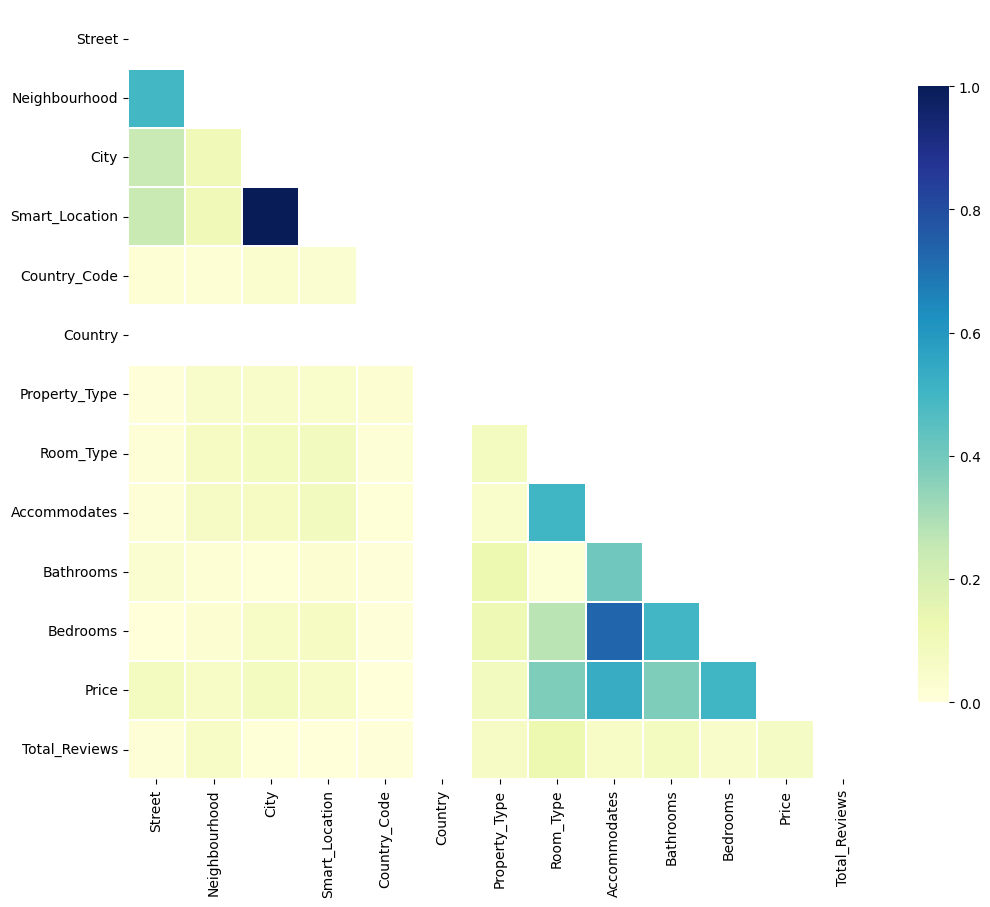

In [79]:
#Gráfica
import seaborn as sns

# Compute the correlation matrix
corr = np.abs(airbnb_df.corr())

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()

In [83]:
#Se elimina la columna que tienen la misma correlación por lo que seria redundante en nuestro modelo
airbnb_df = airbnb_df.drop(['Smart_Location'], axis=1)
#airbnb_df.info()

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

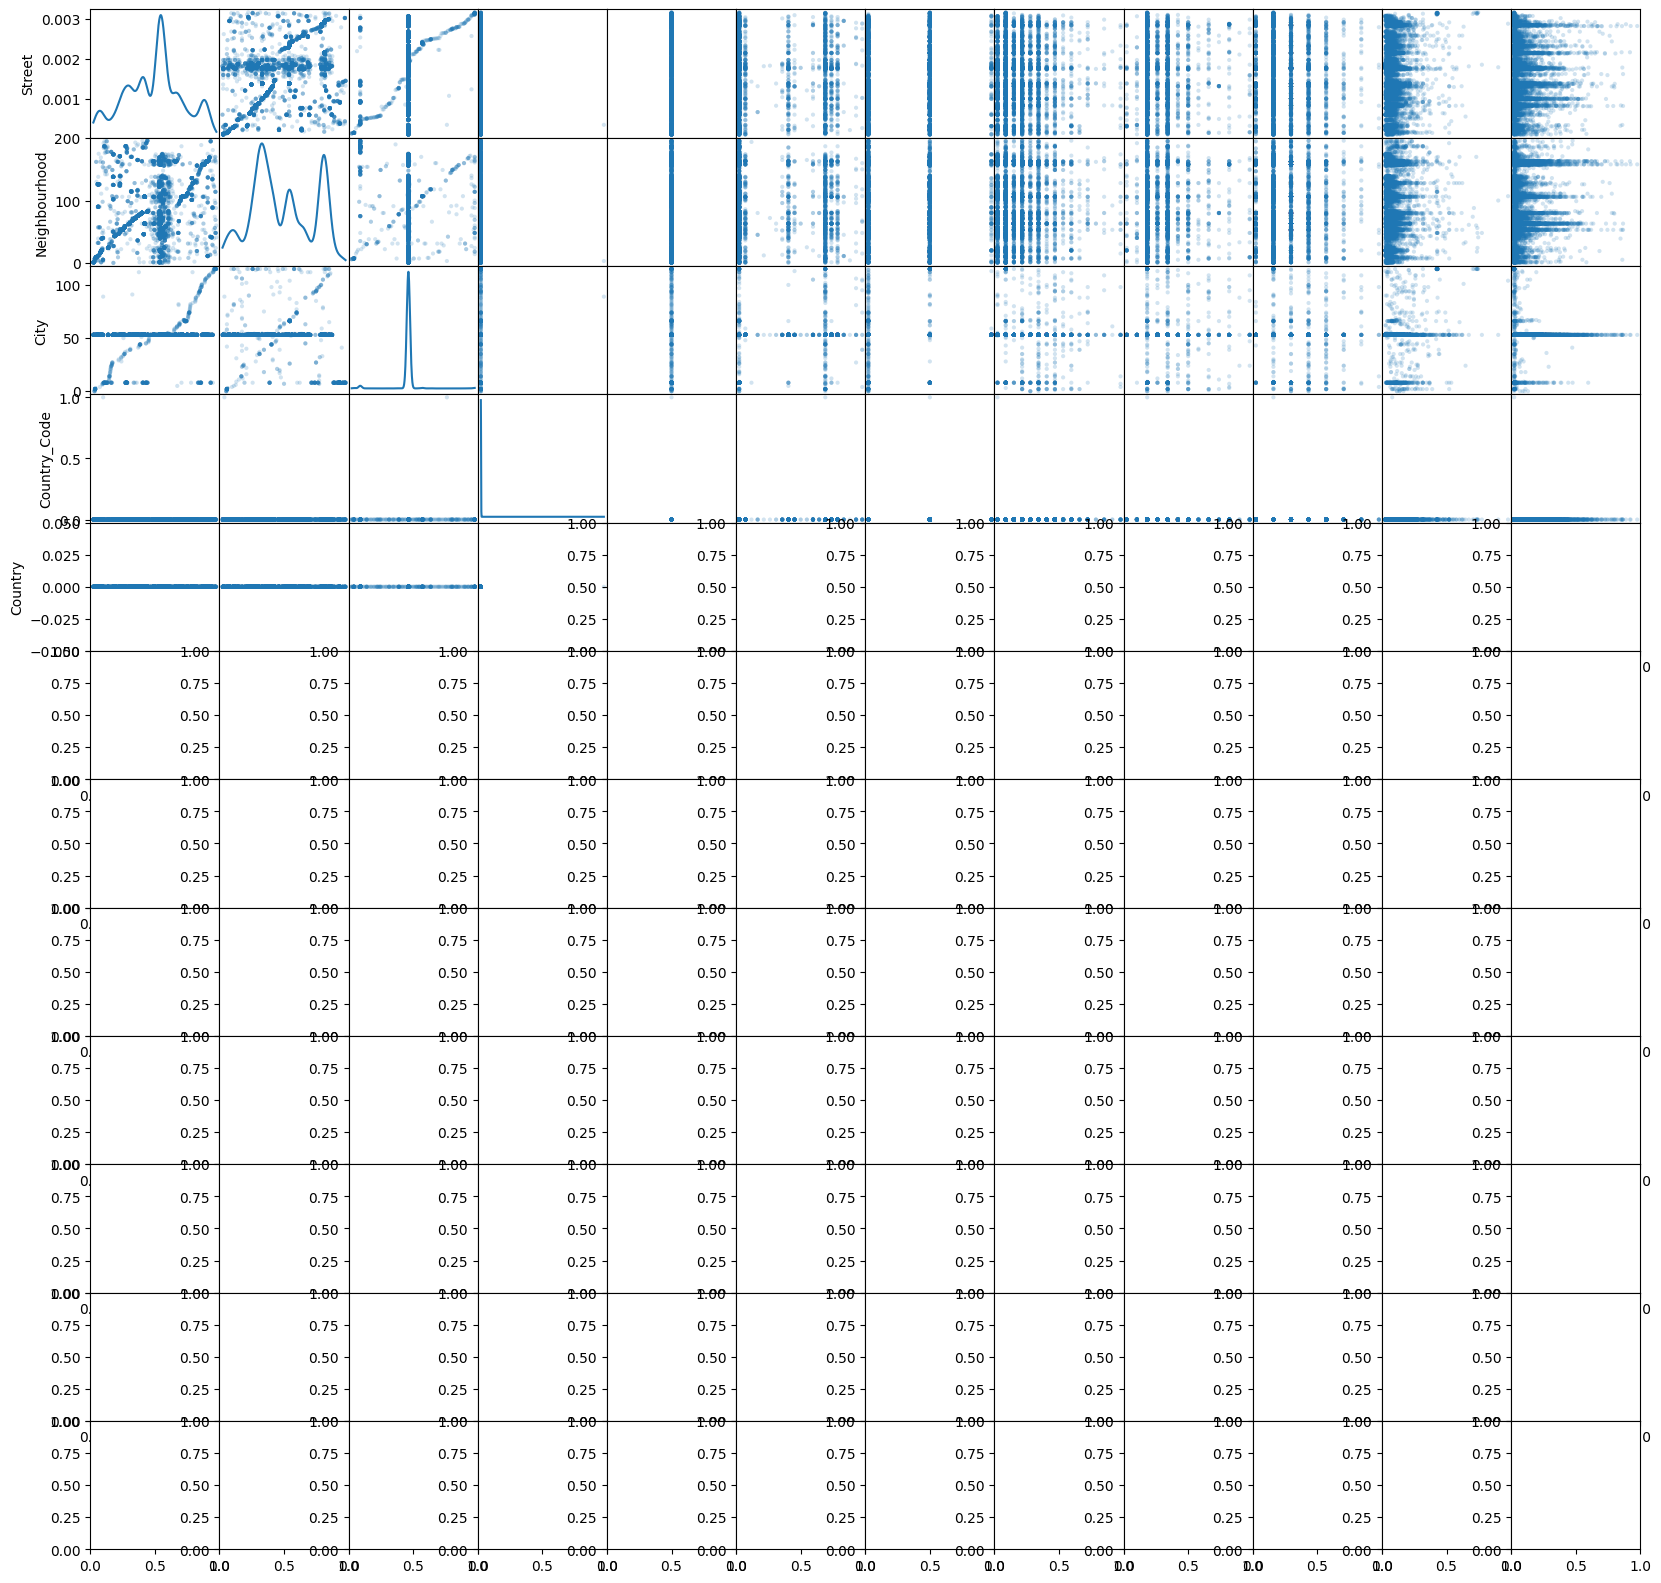

In [85]:
pd.plotting.scatter_matrix(airbnb_df, alpha=0.2, figsize=(20, 20), diagonal = 'kde')
plt.show()

### 4. Generación de nuevas caracteristicas

In [ ]:
### 5. Modelado, cross-validation y estudio de resultados en train y test

In [ ]:
#Extraemos X_train y y_train
X_train_raw = airbnb_df[['Street', 'Neighbourhood Cleansed', 'City', 'Smart Location',
                     'Country Code', 'Country', 'Property Type', 'Room Type', 'Accommodates',
                     'Bathrooms','Bedrooms', 'Number of Reviews']]

#Reemplazo de columnas
X_train_raw.columns = ['Street', 'Neighbourhood', 'City', 'Smart_Location',
                     'Country_Code', 'Country', 'Property_Type', 'Room_Type', 'Accommodates',
                     'Bathrooms','Bedrooms', 'Total_Reviews']

print(f'Dataset X_train: {X_train_raw.shape}')

y_train = airbnb_df['Price']
print(f'Dataset y_train: {y_train.shape}')